In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('dark_background')

,num_rolls,Sequence
0,2,TH
1,1,H
2,1,H
3,1,H
4,1,H
...,...,...
95,1,H
96,1,H
97,1,H
98,1,H


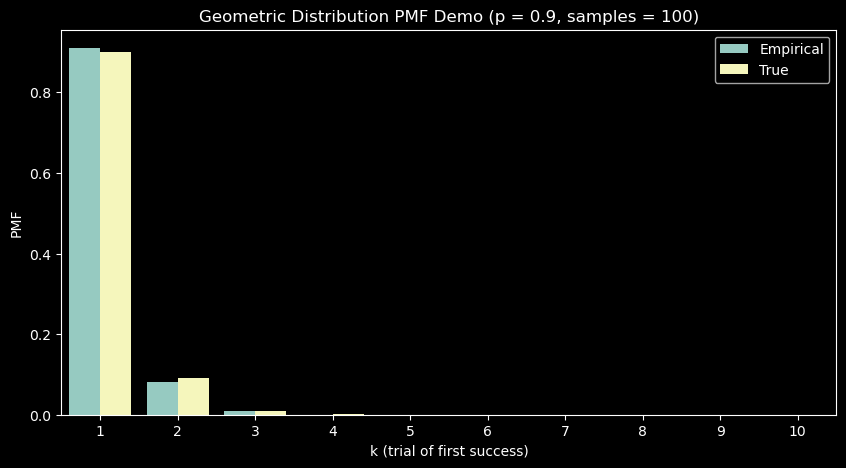

In [28]:
# ======================================================
# PARAMETERS
# ======================================================
p = 0.9              # success probability
num_samples = 100   # number of geometric draws
max_k = 10           # range of k values to display in barplot

# ======================================================
# SIMULATE GEOMETRIC DISTRIBUTION
# ======================================================
samples = np.random.geometric(p, size=num_samples)

# Empirical frequencies
values, counts = np.unique(samples, return_counts=True)

# Build TT...TH strings
sequences = [(k-1)*"T" + "H" for k in samples]

df2 = pd.DataFrame({
    "num_rolls": samples,
    "Sequence": sequences
})
display(df2)

empirical = np.zeros(max_k)
for v, c in zip(values, counts):
    if 1 <= v <= max_k:
        empirical[v-1] = c
empirical = empirical / num_samples

# True PMF
k_vals = np.arange(1, max_k+1)
true_pmf = (1 - p)**(k_vals - 1) * p

df = pd.DataFrame({
    "k": k_vals,
    "Empirical": empirical,
    "True": true_pmf
})

# ======================================================
# THEORETICAL MEAN AND SD LINES
# ======================================================
true_mean = 1 / p
true_sd   = np.sqrt((1 - p) / p**2)

m_minus = true_mean - true_sd
m_plus  = true_mean + true_sd

# ======================================================
# BAR PLOT — EMPIRICAL VS TRUE PMF
# ======================================================
plt.figure(figsize=(10,5))
sns.barplot(
    data=df.melt(id_vars="k", var_name="Type", value_name="PMF"),
    x="k", y="PMF", hue="Type"
)

# Vertical dashed lines for mean ± sd
#plt.axvline(true_mean, color="b", linestyle="--", linewidth=1, label="mean")
#plt.axvline(m_minus, color="r", linestyle="--", linewidth=1)
#plt.axvline(m_plus, color="r", linestyle="--", linewidth=1)

plt.title(f"Geometric Distribution PMF Demo (p = {p}, samples = {num_samples})")
plt.xlabel("k (trial of first success)")
plt.legend()
plt.show()

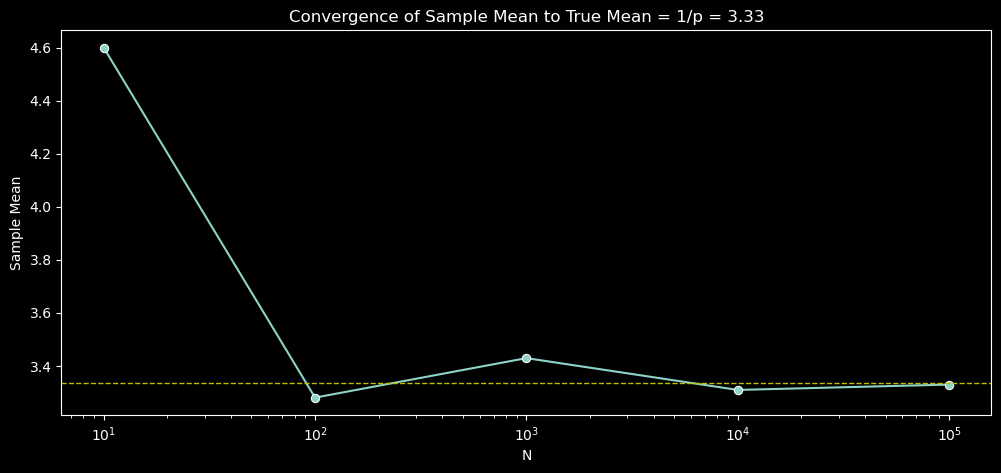

In [7]:
# ======================================================
# SHOW CONVERGENCE OF MEAN
# ======================================================
sample_sizes = [10, 100, 1000, 10000, 100000]
mean_records = []

for N in sample_sizes:
    s = np.random.geometric(p, size=N)
    mean_records.append({"N": N, "EmpiricalMean": np.mean(s)})

df_mean = pd.DataFrame(mean_records)

true_mean = 1/p

plt.figure(figsize=(12,5))
sns.lineplot(data=df_mean, x="N", y="EmpiricalMean", marker="o")
plt.axhline(true_mean, color="y", linestyle="--", linewidth=1)
plt.xscale("log")
plt.title(f"Convergence of Sample Mean to True Mean = 1/p = {true_mean:.2f}")
plt.ylabel("Sample Mean")
plt.show()